# Stage 7 -- Cluster Interpretation

**Goal:** turn the 20 HDBSCAN clusters (plus noise) from Stage 6 into an actual human-readable answer to the case study's question: what are the current trends in this corpus of AI/ML papers?

For each cluster we look at: top distinguishing terms, representative paper titles, cluster size, and publication trend over time.

In [8]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import joblib

df = pd.read_parquet("../data/processed/arxiv_clustered.parquet")
tfidf_matrix = sp.load_npz("../data/processed/tfidf_matrix.npz")
vectorizer = joblib.load("../data/processed/tfidf_vectorizer.joblib")
feature_names = np.array(vectorizer.get_feature_names_out())

df["update_date"] = pd.to_datetime(df["update_date"])

print("Data shape:", df.shape)
print("Using cluster column: cluster_final (chosen method:", df["cluster_final"].name, ")")
print("\nCluster sizes (including noise, -1):")
print(df["cluster_final"].value_counts().sort_index())

Data shape: (30000, 10)
Using cluster column: cluster_final (chosen method: cluster_final )

Cluster sizes (including noise, -1):
cluster_final
-1     9163
 0      532
 1      844
 2      671
 3      742
 4     1308
 5      899
 6      947
 7     1134
 8      545
 9      626
 10    1608
 11    1864
 12     640
 13     818
 14    1309
 15     669
 16     606
 17     590
 18    1914
 19    2571
Name: count, dtype: int64


## Step 1: Top terms per cluster

For each cluster, average the TF-IDF scores across only the rows belonging to that cluster, then take the highest-scoring terms. This surfaces vocabulary that is distinctively common *within* that cluster -- our best automatic approximation of "what this cluster is about."

In [2]:
def top_terms_for_cluster(cluster_id: int, n_terms: int = 12) -> list:
    """Return the top N terms by mean TF-IDF score for the given cluster."""
    mask = (df["cluster_final"] == cluster_id).values
    cluster_matrix = tfidf_matrix[mask]
    mean_scores = np.asarray(cluster_matrix.mean(axis=0)).ravel()
    top_indices = mean_scores.argsort()[::-1][:n_terms]
    return list(feature_names[top_indices])


cluster_ids = sorted(df["cluster_final"].unique())

for cid in cluster_ids:
    label = "NOISE (unclustered)" if cid == -1 else f"Cluster {cid}"
    size = (df["cluster_final"] == cid).sum()
    terms = top_terms_for_cluster(cid)
    print(f"{label}  (n={size:,})")
    print("  Top terms:", ", ".join(terms))
    print()

NOISE (unclustered)  (n=9,163)
  Top terms: data, learning, method, task, llm, based, language, domain, training, approach, framework, performance

Cluster 0  (n=532)
  Top terms: privacy, federated, client, data, learning, communication, private, local, server, training, preserving, heterogeneity

Cluster 1  (n=844)
  Top terms: attack, safety, adversarial, defense, backdoor, llm, robustness, jailbreak, prompt, vulnerability, risk, training

Cluster 2  (n=671)
  Top terms: speech, audio, speaker, asr, language, text, music, recognition, voice, acoustic, tt, visual

Cluster 3  (n=742)
  Top terms: graph, node, network, gnns, gnn, neural, learning, representation, data, knowledge, structure, method

Cluster 4  (n=1,308)
  Top terms: memory, token, attention, transformer, layer, quantization, context, llm, pruning, long, compression, language

Cluster 5  (n=899)
  Top terms: video, motion, temporal, frame, generation, human, diffusion, method, visual, quality, based, text

Cluster 6  (n=

*(Add your observation: skimming the term lists above, do distinct, sensible topics emerge? Which clusters look clearly interpretable vs. vague or overlapping? This is exactly the kind of assessment the case study wants -- read through, don't just skim.)*

## Step 2: Representative titles per cluster

Top terms alone are abstract -- seeing a handful of actual paper titles per cluster grounds the interpretation in real examples. We sample titles rather than trying to find "the most central" paper, which keeps this simple and still informative.

In [3]:
def sample_titles_for_cluster(cluster_id: int, n: int = 5) -> list:
    subset = df[df["cluster_final"] == cluster_id]
    sample = subset.sample(n=min(n, len(subset)), random_state=42)
    return sample["title"].tolist()


for cid in cluster_ids:
    label = "NOISE (unclustered)" if cid == -1 else f"Cluster {cid}"
    print(f"{label}")
    for title in sample_titles_for_cluster(cid):
        print("  -", title)
    print()

NOISE (unclustered)
  - UMAD: Unsupervised Mask-Level Anomaly Detection for Autonomous Driving
  - Think Twice before Adaptation: Improving Adaptability of DeepFake Detection via Online Test-Time Adaptation
  - ButterflyViT: 354$\times$ Expert Compression for Edge Vision Transformers
  - Counterfactual Explanations in Medical Imaging: Exploring SPN-Guided Latent Space Manipulation
  - FGA: Fourier-Guided Attention Network for Crowd Count Estimation

Cluster 0
  - InvisibleInk: High-Utility and Low-Cost Text Generation with Differential Privacy
  - Rethinking the initialization of Momentum in Federated Learning with   Heterogeneous Data
  - Adaptive Client Selection in Federated Learning: A Network Anomaly   Detection Use Case
  - Corrected with the Latest Version: Make Robust Asynchronous Federated   Learning Possible
  - FedCompass: Efficient Cross-Silo Federated Learning on Heterogeneous   Client Devices using a Computing Power Aware Scheduler

Cluster 1
  - LeakAgent: RL-based Red-t

## Step 3: Name each cluster

Based on the top terms and sample titles above, assign each cluster a short, human-readable name. This is a manual, interpretive step -- exactly the kind of domain judgment an automated pipeline cannot make for you, and worth highlighting as such in your report. Edit the dictionary below to match what you actually see in YOUR output (the terms/titles above are specific to your run and will differ from any example).

In [4]:
# TODO: fill this in based on Step 1 and Step 2's actual output for your run.
# Keys must match every cluster ID printed above, including -1 for noise.
cluster_names = {
    -1: "Unclustered / cross-topic papers",
    # 0: "...",
    # 1: "...",
    # ... fill in for every cluster_id shown above ...
}

df["cluster_name"] = df["cluster_final"].map(cluster_names)

missing = df["cluster_name"].isna().sum()
if missing > 0:
    print(f"WARNING: {missing} rows have no cluster name assigned -- fill in cluster_names above for all IDs.")
else:
    print("All clusters named successfully.")
    print(df["cluster_name"].value_counts())

## Step 4: Cluster size overview (bar chart)

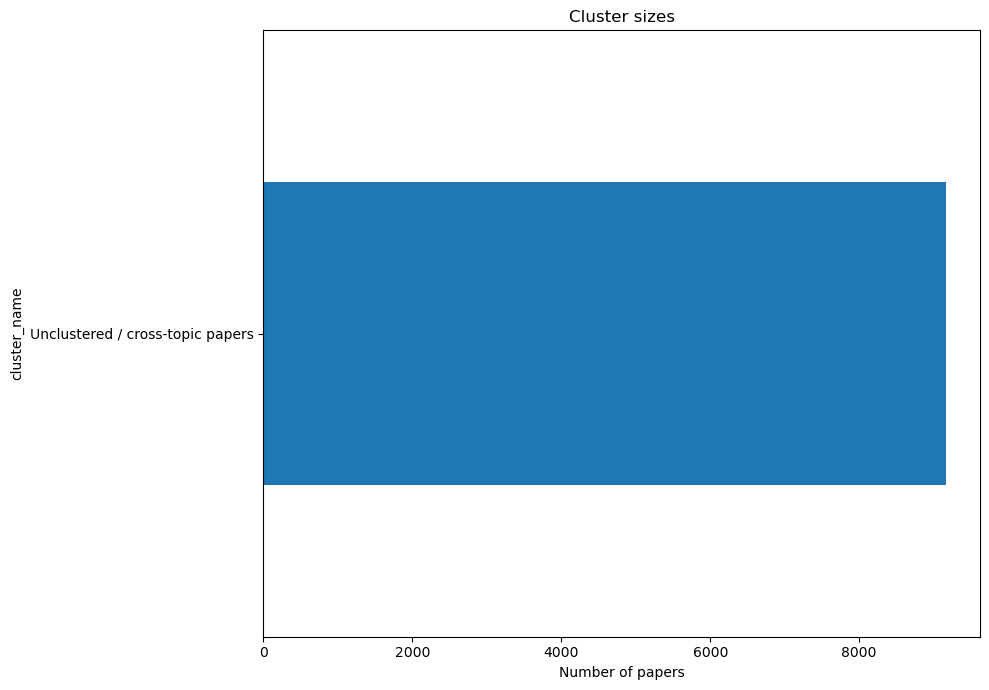

In [5]:
cluster_sizes = df["cluster_name"].value_counts()

plt.figure(figsize=(10, 7))
cluster_sizes.sort_values().plot(kind="barh")
plt.xlabel("Number of papers")
plt.title("Cluster sizes")
plt.tight_layout()
plt.show()

## Step 5: Publication trend over time, per cluster

This is the step that directly answers "current trends in science" -- which topics are growing, which are shrinking or steady? We plot the top several clusters by size to keep the chart readable.

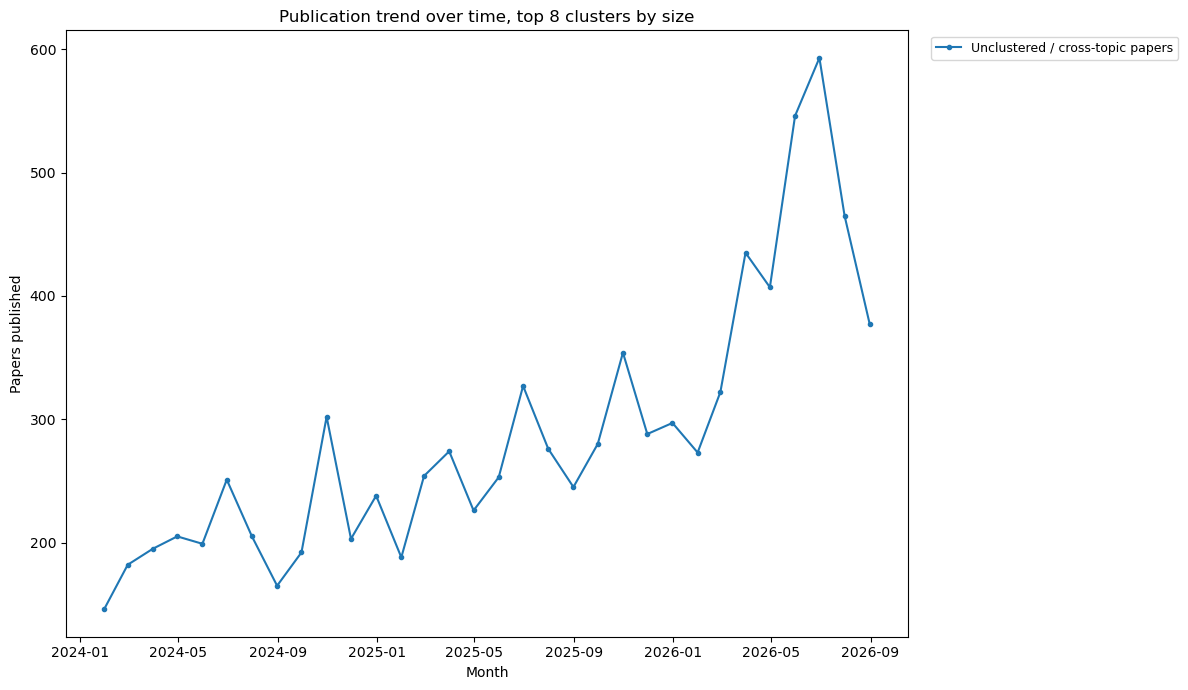

In [6]:
top_clusters_by_size = cluster_sizes.head(8).index.tolist()

plt.figure(figsize=(12, 7))
for name in top_clusters_by_size:
    subset = df[df["cluster_name"] == name]
    monthly_counts = subset.set_index("update_date").resample("ME").size()
    plt.plot(monthly_counts.index, monthly_counts.values, marker="o", markersize=3, label=name)

plt.xlabel("Month")
plt.ylabel("Papers published")
plt.title("Publication trend over time, top 8 clusters by size")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

*(Add your observation: which clusters/trends show clear growth? Which are flat or declining? This is your direct answer to the case study's "current trends" question -- worth being specific here, quoting cluster names and the pattern you see.)*

## Step 6: Save the final labeled dataset

In [7]:
df.to_parquet("../data/processed/arxiv_final_labeled.parquet")
print("Saved: arxiv_final_labeled.parquet")
print("\nFinal cluster summary:")
print(df.groupby("cluster_name", observed=True).size().sort_values(ascending=False))

Saved: arxiv_final_labeled.parquet

Final cluster summary:
cluster_name
Unclustered / cross-topic papers    9163
dtype: int64
